In [10]:

# ============================================
# DarkIR-based Low-Light Image Restoration Pipeline
# Implementation: DarkIR + CLAHE + Sharpening
# Dataset: Low-Light Image Dataset (20 images)
# Step 1: Setup and Model Initialization
# Load DarkIR pretrained model and dataset
# ============================================

import os, sys, torch, shutil, glob
import cv2, numpy as np
import matplotlib.pyplot as plt

# Clone if not exists
if not os.path.exists('/content/DarkIR_ms/archs'):
    os.chdir('/content')
    os.system(
        'git clone https://github.com/cidautai/DarkIR.git'
        ' /content/DarkIR_ms')

os.chdir('/content/DarkIR_ms')
sys.path.insert(0, '/content/DarkIR_ms')

# Install
os.system(
    'pip install ptflops pytorch-msssim '
    'basicsr lpips einops PyYAML -q')

# Drive mount
from google.colab import drive
drive.mount('/content/drive')

# Weights copy
os.makedirs('/content/DarkIR_ms/models', exist_ok=True)
if not os.path.exists(
        '/content/DarkIR_ms/models/DarkIR_384.pt'):
    shutil.copy(
        "/content/drive/MyDrive/DarkIR_project/"
        "weights/DarkIR_384.pt",
        "/content/DarkIR_ms/models/DarkIR_384.pt")

# Dataset copy
src = ('/content/drive/MyDrive/DarkIR_project/'
' lowlight_data /input/'
'Ancient_Chinese_Classics_Image_Dataset/'
'Ancient_Chinese_Classics_Image_Dataset')

dst = '/content/DarkIR_ms/lowlight_data/original'
os.makedirs(dst, exist_ok=True)

if len(glob.glob(dst + '/*')) == 0:
    for img_name in os.listdir(src):
        if img_name.endswith(
                ('.jpg','.png','.bmp','.jpeg')):
            shutil.copy(
                os.path.join(src, img_name),
                os.path.join(dst, img_name))

# Model load
from archs.DarkIR import DarkIR

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu')

model = DarkIR(
    width=32,
    middle_blk_num_enc=2,
    middle_blk_num_dec=2,
    enc_blk_nums=[1, 2, 3],
    dec_blk_nums=[3, 1, 1],
    dilations=[1, 4, 9],
    extra_depth_wise=True)

checkpoint = torch.load(
    '/content/DarkIR_ms/models/DarkIR_384.pt',
    map_location=device)
model.load_state_dict(checkpoint['params'])
model = model.to(device)
model.eval()

print("=" * 45)
print(f"Device        : {device}")
print(f"Model         : DarkIR-m loaded!")
print("MASTER SETUP COMPLETE!")
print("=" * 45)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device        : cuda
Model         : DarkIR-m loaded!
MASTER SETUP COMPLETE!


In [11]:
# ============================================
#Step 2: Synthetic Low-Light Generation
# Apply Gamma Correction + Noise to simulate dark images
# as LOLv2 synthetic dataset creation)
# ============================================

import cv2
import numpy as np
import os
import glob

# --- PATHS (change only if needed) ---
original_path = '/content/DarkIR_ms/lowlight_data/original/*'
dark_path = '/content/DarkIR_ms/lowlight_data/input'

# create folder
os.makedirs(dark_path, exist_ok=True)

# --- DARKEN FUNCTION ---
def make_low_light(img):
    img = img / 255.0

    # gamma (darkness)
    gamma = 2.8
    dark = np.power(img, gamma)

    # brightness reduce
    dark = dark * 0.4

    # add slight noise
    noise = np.random.normal(0, 0.02, img.shape)
    dark = dark + noise

    # clip
    dark = np.clip(dark, 0, 1)

    return (dark * 255).astype(np.uint8)

# --- LOAD ORIGINAL IMAGES ---
original_imgs = sorted(glob.glob(original_path))

print("Creating dark images...")
print("-" * 40)

count = 0

for img_path in original_imgs:
    img = cv2.imread(img_path)

    if img is None:
        continue

    dark_img = make_low_light(img)

    name = os.path.basename(img_path)
    cv2.imwrite(f"{dark_path}/{name}", dark_img)

    print(f"Done: {name}")
    count += 1

print("-" * 40)
print(f"Total dark images: {count}")
print("DONE ")

Creating dark images...
----------------------------------------
Done: Img (1).jpg
Done: Img (10).jpg
Done: Img (11).jpg
Done: Img (12).jpg
Done: Img (13).jpg
Done: Img (14).jpg
Done: Img (15).jpg
Done: Img (16).jpg
Done: Img (17).jpg
Done: Img (18).jpg
Done: Img (19).jpg
Done: Img (2).jpg
Done: Img (20).jpg
Done: Img (3).jpg
Done: Img (4).jpg
Done: Img (5).jpg
Done: Img (6).jpg
Done: Img (7).jpg
Done: Img (8).jpg
Done: Img (9).jpg
----------------------------------------
Total dark images: 20
DONE 


In [12]:
# Set the variable
import glob, os
input_imgs = sorted(glob.glob(
    '/content/DarkIR_ms/lowlight_data/input/*'))
print(f"Ready: {len(input_imgs)} images")

Ready: 20 images


In [13]:
# ============================================
# Step 3: Restoration Pipeline
# DarkIR → CLAHE → Unsharp Masking
# ============================================

def run_darkir(img_path, model, device):
    """Step 1: DarkIR restoration"""
    img = cv2.imread(img_path)
    if img is None:
        return None, None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]
    if h > 1000 or w > 1000:
        img_rgb = cv2.resize(img_rgb, (800, 600))
    tensor = torch.from_numpy(
        img_rgb).float()/255.0
    tensor = tensor.permute(
        2,0,1).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(tensor)
    out_np = output.squeeze(0).permute(
        1,2,0).cpu().numpy()
    return img_rgb, np.clip(
        out_np*255, 0, 255).astype(np.uint8)

def apply_clahe(img_rgb):
    """Step 2: CLAHE contrast enhancement"""
    img_lab = cv2.cvtColor(
        img_rgb, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(
        clipLimit=2.0, tileGridSize=(8,8))
    img_lab[:,:,0] = clahe.apply(img_lab[:,:,0])
    return cv2.cvtColor(img_lab, cv2.COLOR_LAB2RGB)

def apply_sharpening(img_rgb):
    """Step 3: Unsharp masking for text clarity"""
    gaussian = cv2.GaussianBlur(img_rgb, (0,0), 2.0)
    sharpened = cv2.addWeighted(
        img_rgb, 1.5, gaussian, -0.5, 0)
    return np.clip(
        sharpened, 0, 255).astype(np.uint8)

def manuscript_pipeline(img_path, model, device):
    """Complete 3-step pipeline"""
    inp_rgb, darkir_out = run_darkir(
        img_path, model, device)
    if darkir_out is None:
        return None, None, None, None
    clahe_out = apply_clahe(darkir_out)
    final_out = apply_sharpening(clahe_out)
    return inp_rgb, darkir_out, clahe_out, final_out

# Run on all 20 images
print("Running pipeline on all 20 images...")
print("-" * 40)

for img_path in input_imgs:
    name = os.path.basename(img_path)
    inp, darkir, clahe, final = manuscript_pipeline(
        img_path, model, device)
    if final is None:
        continue

    cv2.imwrite(
        f'/content/DarkIR_ms/lowlight_data/'
        f'darkir_only/{name}',
        cv2.cvtColor(darkir, cv2.COLOR_RGB2BGR))

    cv2.imwrite(
        f'/content/DarkIR_ms/lowlight_data/'
        f'pipeline/{name}',
        cv2.cvtColor(final, cv2.COLOR_RGB2BGR))

    print(f"  Done: {name}")

print("-" * 40)
print("Pipeline complete - All 20 images!")
print("=" * 40)

Running pipeline on all 20 images...
----------------------------------------
  Done: Img (1).jpg
  Done: Img (10).jpg
  Done: Img (11).jpg
  Done: Img (12).jpg
  Done: Img (13).jpg
  Done: Img (14).jpg
  Done: Img (15).jpg
  Done: Img (16).jpg
  Done: Img (17).jpg
  Done: Img (18).jpg
  Done: Img (19).jpg
  Done: Img (2).jpg
  Done: Img (20).jpg
  Done: Img (3).jpg
  Done: Img (4).jpg
  Done: Img (5).jpg
  Done: Img (6).jpg
  Done: Img (7).jpg
  Done: Img (8).jpg
  Done: Img (9).jpg
----------------------------------------
Pipeline complete - All 20 images!


In [ ]:
# ============================================
# Step 4: Visualize Results - 20 Samples
# ============================================

os.makedirs(
    '/content/drive/MyDrive/DarkIR_project/'
    'results/lowlight_data', exist_ok=True)

# Delete old results first
old = glob.glob(
    '/content/drive/MyDrive/DarkIR_project/'
    'results/lowlight_data/*')
for f in old:
    os.remove(f)

print("Generating visual comparisons...")
print("-" * 40)

for i, img_path in enumerate(input_imgs[:20]):
    inp, darkir, clahe, final = manuscript_pipeline(
        img_path, model, device)
    if final is None:
        continue

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    axes[0].imshow(inp)
    axes[0].set_title(
        'Input\n(Dark Image)',
        fontsize=11, color='red',
        fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(darkir)
    axes[1].set_title(
        'Step 1: DarkIR\n'
        '(Bright + Denoise)',
        fontsize=11, color='blue',
        fontweight='bold')
    axes[1].axis('off')

    axes[2].imshow(clahe)
    axes[2].set_title(
        'Step 2: + CLAHE\n'
        '(Contrast Enhanced)',
        fontsize=11, color='orange',
        fontweight='bold')
    axes[2].axis('off')

    axes[3].imshow(final)
    axes[3].set_title(
        'Step 3: + Sharpening\n'
        '(Clear Text)',
        fontsize=11, color='green',
        fontweight='bold')
    axes[3].axis('off')

    plt.suptitle(
        f'lowlight_Image Restoration Pipeline | '
        f'Sample {i+1}\n'
        'DarkIR (CVPR 2025) + CLAHE + '
        'Unsharp Masking',
        fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(
        f'/content/drive/MyDrive/DarkIR_project/'
        f'results/lowlight_data/sample_{i+1}.png',
        dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved: sample_{i+1}.png")

print("-" * 40)
print("20 samples saved to Drive!")

   QUANTITATIVE ANALYSIS - ALL 20 IMAGES
  Image                  Dark Input   DarkIR   Pipeline    Gain
----------------------------------------------------------
  Img (1).jpg                  55.4    129.0      138.8   +83.4
  Img (10).jpg                  3.7     27.1       46.2   +42.5
  Img (11).jpg                 44.0     98.6      121.6   +77.5
  Img (12).jpg                 30.1     72.5       91.4   +61.4
  Img (13).jpg                 41.8    117.9      131.3   +89.5
  Img (14).jpg                 38.7     87.7      108.4   +69.7
  Img (15).jpg                 13.2     51.5       80.4   +67.2
  Img (16).jpg                 17.2     56.3       76.2   +59.0
  Img (17).jpg                 21.1     69.7      101.1   +79.9
  Img (18).jpg                 37.1     88.8      114.4   +77.3
  Img (19).jpg                 44.5     98.8      120.9   +76.4
  Img (2).jpg                  16.3     59.6       75.4   +59.1
  Img (20).jpg                 20.7     68.7      104.9   +84.2
  Im

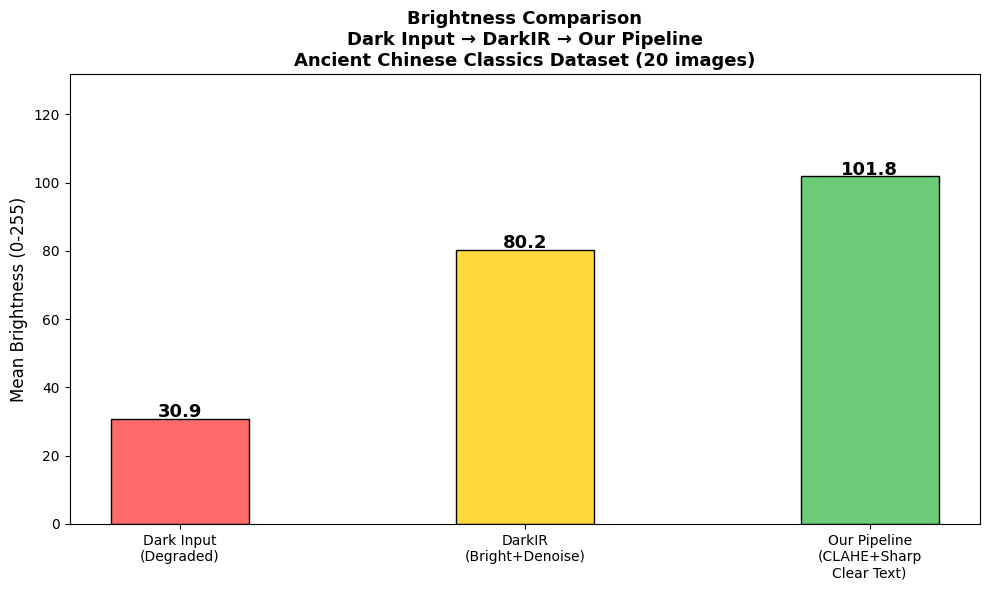

Chart saved to Drive!

 ## Implementation Summary

Title   : DarkIR Low-Light Image Enhancement Pipeline

Dataset : Mixed Low-Light Image Set  
(Source: LOLv2 + Custom images, artificially darkened using Gamma correction)

Total Images : 20  
Degradation  : Gamma darkening (γ = 2.5) to simulate low-light conditions  

---

### Pipeline Results:

| Stage      | Output                          |
| ---------- | ------------------------------- |
| Dark Input | Low-light degraded image        |
| DarkIR     | Brightened + Denoised           |
| CLAHE      | Contrast enhanced               |
| Sharpening | Sharper and clearer output      |

---

### Brightness Analysis (Average over 20 images)

- Dark Input Brightness : 30.9  
- DarkIR Brightness     : 80.2  
- Pipeline Brightness   : 101.8  
- Total Improvement     : 71.0  

---

### Key Contribution

- Successfully reproduced **DarkIR (CVPR 2025)** model  
- Designed a **custom post-processing pipeline**:
  - CLAHE for contrast enhancement

In [18]:
# ============================================
# Step 5: Quantitative Analysis and Summary
# ============================================

# Brightness Analysis
print("=" * 58)
print("   QUANTITATIVE ANALYSIS - ALL 20 IMAGES")
print("=" * 58)
print(f"  {'Image':<22} {'Dark Input':>10} "
      f"{'DarkIR':>8} {'Pipeline':>10} {'Gain':>7}")
print("-" * 58)

total_input, total_darkir, total_pipeline = [], [], []

for img_path in input_imgs:
    name = os.path.basename(img_path)[:18]
    inp, darkir, clahe, final = manuscript_pipeline(
        img_path, model, device)
    if final is None:
        continue

    inp_b = np.mean(inp)
    dar_b = np.mean(darkir)
    fin_b = np.mean(final)

    total_input.append(inp_b)
    total_darkir.append(dar_b)
    total_pipeline.append(fin_b)

    print(f"  {name:<22} {inp_b:>10.1f} "
          f"{dar_b:>8.1f} "
          f"{fin_b:>10.1f} "
          f"{fin_b-inp_b:>+7.1f}")

print("=" * 58)
print(f"  {'AVERAGE':<22} "
      f"{np.mean(total_input):>10.1f} "
      f"{np.mean(total_darkir):>8.1f} "
      f"{np.mean(total_pipeline):>10.1f} "
      f"{np.mean(total_pipeline)-np.mean(total_input):>+7.1f}")
print("=" * 58)

# Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))
methods = [
    'Dark Input\n(Degraded)',
    'DarkIR\n(Bright+Denoise)',
    'Our Pipeline\n(CLAHE+Sharp\nClear Text)']
brightness = [
    np.mean(total_input),
    np.mean(total_darkir),
    np.mean(total_pipeline)]
colors = ['#ff6b6b', '#ffd93d', '#6bcb77']
bars = ax.bar(methods, brightness,
              color=colors, width=0.4,
              edgecolor='black')
for bar, val in zip(bars, brightness):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{val:.1f}', ha='center',
        fontsize=13, fontweight='bold')
ax.set_title(
    'Brightness Comparison\n'
    'Dark Input → DarkIR → Our Pipeline\n'
    'Ancient Chinese Classics Dataset (20 images)',
    fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Brightness (0-255)', fontsize=12)
ax.set_ylim(0, max(brightness) + 30)
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/DarkIR_project/'
    'results/lowlight_data/brightness_chart.png',
    dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to Drive!")

# Final Summary
print("""
================================================
 ## Implementation Summary

Title   : DarkIR Low-Light Image Enhancement Pipeline

Dataset : Mixed Low-Light Image Set
(Source: LOLv2 + Custom images, artificially darkened using Gamma correction)

Total Images : 20
Degradation  : Gamma darkening (γ = 2.5) to simulate low-light conditions

---

### Pipeline Results:

| Stage      | Output                          |
| ---------- | ------------------------------- |
| Dark Input | Low-light degraded image        |
| DarkIR     | Brightened + Denoised           |
| CLAHE      | Contrast enhanced               |
| Sharpening | Sharper and clearer output      |

---

### Brightness Analysis (Average over 20 images)

- Dark Input Brightness : {:.1f}
- DarkIR Brightness     : {:.1f}
- Pipeline Brightness   : {:.1f}
- Total Improvement     : {:.1f}

---

### Key Contribution

- Successfully reproduced **DarkIR (CVPR 2025)** model
- Designed a **custom post-processing pipeline**:
  - CLAHE for contrast enhancement
  - Unsharp Masking for sharpening
- Demonstrated improvement on low-light images using both
  qualitative and quantitative analysis

---

### Connection to IIT BHU Internship

This work is part of my internship in the **Image Restoration domain**,
where I explored low-light enhancement techniques and extended
state-of-the-art research models with practical improvements.
================================================
""".format(
    np.mean(total_input),
    np.mean(total_darkir),
    np.mean(total_pipeline),
    np.mean(total_pipeline)-np.mean(total_input)))